# smol-doc-analyzer — Full Pipeline Walkthrough

This notebook runs **every implemented stage** of the local insurance-document pipeline end to end:

1. **Characteristic profiling** — refresh layout / OCR / legal-style / insurance priors
2. **Skeleton sampling** — randomized claim skeletons from distribution profiles
3. **Stage A** — synthetic document text (template; optional OpenRouter LLM)
4. **Stage B** — adjuster-style memos (training targets for Phase 4 summarization)
5. **OCR noise** — garbled variants for extraction stress tests
6. **Classification** — prepare → train (smoke DistilBERT) → evaluate
7. **Extraction** — render forms → prepare → train (smoke) → evaluate
8. **Provenance** — inspect the generation/training audit log

> **Demo scale:** uses a modest corpus (`N=160`) and `--smoke` training so it finishes on CPU in minutes while keeping eval metrics meaningful.  
> For production-scale runs, raise `N` and set `SMOKE = False` (DeBERTa-v3 / LayoutLMv3).

**Not yet implemented (Phases 4–5):** LoRA memo model training and the unified intake orchestrator. Stage B memos shown here are the *synthetic targets* those phases will train on.


## 0. Setup

Ensure the repo root is on `sys.path`, load config, and set demo knobs.


In [1]:
from __future__ import annotations

import json
import logging
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

# Resolve repo root whether the kernel cwd is repo root or notebooks/
CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / "pyproject.toml").exists() else CWD.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Could not find repo root from {CWD}"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.utils.config import Config
from src.utils.io import load_jsonl, read_json

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

cfg = Config.load()

# --- Demo knobs ---
N = 160         # skeletons / documents (48 was too small for stable smoke metrics)
SEED = 42
SMOKE = True    # DistilBERT smoke path; set False for DeBERTa / LayoutLMv3

DEMO = REPO_ROOT / "data" / "notebook_demo"
DEMO.mkdir(parents=True, exist_ok=True)

print(f"repo:  {REPO_ROOT}")
print(f"python: {sys.version.split()[0]}")
print(f"LLM key set: {bool(cfg.openrouter_api_key)}")
print(f"N={N}  SEED={SEED}  SMOKE={SMOKE}")
print(f"demo outputs → {DEMO}")


repo:  /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer
python: 3.11.15
LLM key set: False
N=48  SEED=42  SMOKE=True
demo outputs → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo


## 1. Taxonomy — document-type labels

Classification targets come from `taxonomy/acord_form_categories.yaml` (ACORD-inspired; includes a few non-ACORD claim attachments). `adjuster_memo` is a Stage B *output* type and is excluded from Stage A classifier training.


In [2]:
tax = yaml.safe_load(cfg.taxonomy_path.read_text(encoding="utf-8"))
tax_df = pd.DataFrame(
    [
        {
            "label": c["label"],
            "lifecycle_stage": c["lifecycle_stage"],
            "acord_forms": ", ".join(c.get("acord_forms") or []) or "—",
            "description": c["description"].strip().split("\n")[0][:90] + "…",
        }
        for c in tax["categories"]
    ]
)
display(tax_df)
print(f"{len(tax_df)} categories  |  classifier excludes: adjuster_memo")


,label,lifecycle_stage,acord_forms,description
0,application_commercial,underwriting_intake,"125, 126, 140, 127, 130, 131, 146",Commercial insurance applications and coverage...
1,application_personal,underwriting_intake,"90, 80, 83, 84","Personal lines applications: auto, homeowners,..."
2,certificate_evidence,policy_servicing,"24, 25, 27, 28",Certificates and evidence of insurance -- proo...
3,loss_notice,claim_intake,"1, 2",First notice of loss documents for property an...
4,claims_correspondence,claim_processing,—,Free-text correspondence related to an open cl...
5,adjuster_memo,claim_processing,—,Internal case memos written by adjusters summa...
6,policy_change_endorsement,policy_servicing,101,Requests to modify an active policy: endorseme...
7,repair_estimate,claim_processing,—,Third-party repair/replacement cost estimates ...
8,supporting_evidence,claim_processing,—,"Police reports, photos (described, not the ima..."


9 categories  |  classifier excludes: adjuster_memo


## 2. Characteristic profiles

Bundled priors under `data/profiles/` seed generation. `run_profiler` refreshes them from any ingested Hub samples in `data/raw/` (optional; skipped by default).


Profile versions:
  document_surface_profile.json: 1.0.0
  insurance_distributions.json: 1.0.0
  layout_profile.json: 1.0.0
  legal_style_profile.json: 1.0.0
  ocr_noise_profile.json: 1.0.0


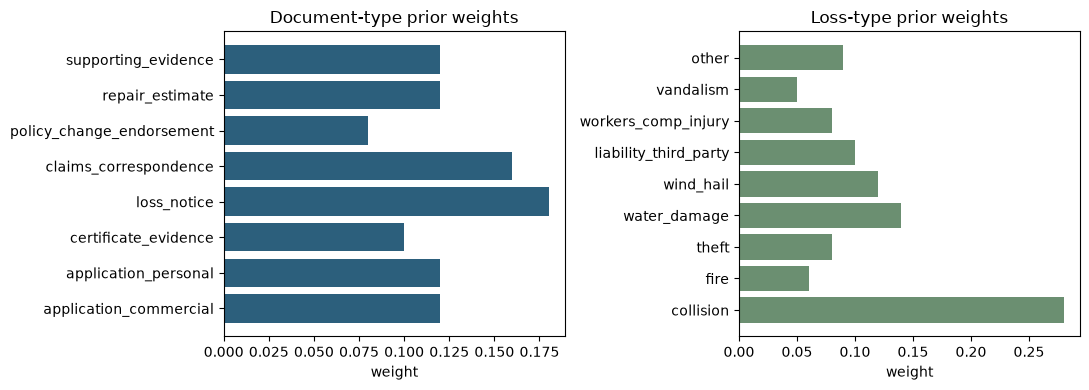

Legal style (vocab only — never used as class labels):
  proximate cause, material fact, coverage determination, reservation of rights, duty to defend, indemnify and hold harmless, preponderance of the evidence, reasonable care …
OCR noise rates: {'char_substitution_rate': 0.025, 'char_deletion_rate': 0.008, 'char_insertion_rate': 0.006}


In [3]:
from src.generation.characteristic_profiler import run_profiler

profile_versions = run_profiler(cfg)
print("Profile versions:")
for name, ver in profile_versions.items():
    print(f"  {name}: {ver}")

dist = read_json(cfg.profiles_dir / "insurance_distributions.json")
legal = read_json(cfg.profiles_dir / "legal_style_profile.json")
ocr = read_json(cfg.profiles_dir / "ocr_noise_profile.json")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
doc_w = dist["document_type_weights"]
axes[0].barh(list(doc_w.keys()), list(doc_w.values()), color="#2c5f7c")
axes[0].set_title("Document-type prior weights")
axes[0].set_xlabel("weight")
loss_w = dist["loss_type_weights"]
axes[1].barh(list(loss_w.keys()), list(loss_w.values()), color="#6b8f71")
axes[1].set_title("Loss-type prior weights")
axes[1].set_xlabel("weight")
plt.tight_layout()
plt.show()

print("Legal style (vocab only — never used as class labels):")
print(" ", ", ".join(legal.get("vocabulary_ngrams", [])[:8]), "…")
print("OCR noise rates:",
      {k: ocr[k] for k in ("char_substitution_rate", "char_deletion_rate", "char_insertion_rate")})


## 3. Skeleton sampling

Each skeleton is a schema-validated claim intermediate (`data/schemas/claim_skeleton.schema.json`) with policy, loss, parties, and financials. Fixed train/val/test splits are written to `data/synthetic/splits.json`.


In [4]:
from src.generation.skeleton_sampler import run_sampler

sk_path = run_sampler(cfg, n=N, seed=SEED, out=DEMO / f"skeletons_n{N}_seed{SEED}.jsonl")
skeletons = load_jsonl(sk_path)
splits = read_json(cfg.splits_path)

print(f"Wrote {len(skeletons)} skeletons → {sk_path}")
print(f"Splits: train={len(splits['train'])}  val={len(splits['val'])}  test={len(splits['test'])}")

type_counts = Counter(s["document_type"] for s in skeletons)
display(pd.DataFrame(type_counts.most_common(), columns=["document_type", "count"]))

sample = skeletons[0]
display(Markdown(f"### Sample skeleton — `{sample['claim_id']}` / `{sample['document_type']}`"))
print(json.dumps(sample, indent=2)[:1800])


Wrote 48 skeletons → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/skeletons_n48_seed42.jsonl
Splits: train=34  val=7  test=7


,document_type,count
0,loss_notice,9
1,claims_correspondence,8
2,repair_estimate,8
3,supporting_evidence,6
4,policy_change_endorsement,5
5,application_personal,4
6,certificate_evidence,4
7,application_commercial,4


### Sample skeleton — `CLM-2025-666564` / `claims_correspondence`

{
  "claim_id": "CLM-2025-666564",
  "document_type": "claims_correspondence",
  "acord_form_number": null,
  "policy": {
    "policy_number": "AZ-974628-L",
    "policyholder_name": "Harper Young",
    "state": "AZ",
    "coverage_type": "commercial_general_liability",
    "effective_date": "2025-01-05"
  },
  "loss_event": {
    "date_of_loss": "2025-10-27",
    "loss_type": "other",
    "location": "2764 Hillcrest Ln, AZ",
    "description_seed": "smoke odor infiltration from neighboring unit fire",
    "police_report_filed": true,
    "injuries_reported": false
  },
  "parties": {
    "insured": "Harper Young",
    "claimant": null,
    "adjuster_assigned": "Taylor Brown"
  },
  "financials": {
    "estimated_damage": 13918.95,
    "deductible": 5000.0,
    "reserve_set": 14405.66
  },
  "narrative_complexity": "standard",
  "multi_doc_group_id": null,
  "target_outputs": {
    "document_text": null,
    "memo_text": null
  },
  "_record_id": "CLM-2025-666564::claims_correspondence

## 4. Stage A — document generation

Renders insurance document text from each skeleton using layout + surface + legal-style profiles. If `OPENROUTER_API_KEY` is set, an LLM is tried first with template fallback.


In [5]:
from src.generation.stage_a_document_gen import run_stage_a

doc_path = run_stage_a(cfg, sk_path, out=DEMO / f"documents_n{N}_seed{SEED}.jsonl", seed=SEED)
docs = load_jsonl(doc_path)
modes = Counter(d["generation_mode"] for d in docs)
print(f"Documents: {len(docs)}  modes={dict(modes)}")
print(f"→ {doc_path}")

doc = docs[0]
display(Markdown(f"### Sample document — `{doc['document_type']}` (`{doc['generation_mode']}`)"))
print(doc["text"][:2200])


Documents: 48  modes={'template': 48}
→ /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/documents_n48_seed42.jsonl


### Sample document — `claims_correspondence` (`template`)

Dear Claimant
Claim Number: CLM-2025-666564
ACORD Form: N/A

RE:
Adjuster Name: Taylor Brown
Claim Status: under review (standard)

CLAIM STATUS
Adjuster Name: Taylor Brown
Claim Status: under review (standard)

REQUESTED ACTION
Adjuster Name: Taylor Brown
Claim Status: under review (standard)

NEXT STEPS
Policy Number: AZ-974628-L
Named Insured: Harper Young

NARRATIVE
Subject to further investigation Reference is made to proximate cause. The loss is described as: smoke odor infiltration from neighboring unit fire. Complexity assessment: standard.

Claims Department
Prepared for claim CLM-2025-666564


## 5. Stage B — adjuster memo generation

Produces memo training targets conditioned on the skeleton + Stage A text (issue/rule/application/conclusion style from the legal profile).


In [6]:
from src.generation.stage_b_memo_gen import run_stage_b

memo_path = run_stage_b(cfg, doc_path, out=DEMO / f"memos_n{N}_seed{SEED}.jsonl", seed=SEED)
memos = load_jsonl(memo_path)
print(f"Memos: {len(memos)} → {memo_path}")

memo = memos[0]
display(Markdown(f"### Sample memo — claim `{memo['claim_id']}`"))
print(memo["memo_text"][:2200])


Memos: 48 → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/memos_n48_seed42.jsonl


### Sample memo — claim `CLM-2025-666564`

ADJUSTER MEMO — CLM-2025-666564
To: Claims File
From: Taylor Brown
Re: Harper Young / AZ-974628-L

Summary
Subject to further investigation the reported other loss on 2025-10-27 under commercial_general_liability in AZ.

Facts
- Location: 2764 Hillcrest Ln, AZ
- Description: smoke odor infiltration from neighboring unit fire
- Police report: yes
- Injuries: no
- Estimated damage: $13,918.95
- Deductible: $5,000.00
- Current reserve: $14,405.66

Analysis
The record supports a finding that the claim file for CLM-2025-666564 is standard, because smoke odor infiltration from neighboring unit fire. Alternative explanations are less consistent with the Stage A source document and reported loss details.

Next Steps
- Confirm coverage grant/denial points in writing
- Update reserve if investigation changes exposure
- Request any missing supporting evidence

Source document type: claims_correspondence


## 6. OCR noise injection

Applies character/word-level OCR artifacts from `ocr_noise_profile.json` and builds a multi-document bundle index for grouped claim files.


### Clean vs OCR-noisy (first ~500 chars)

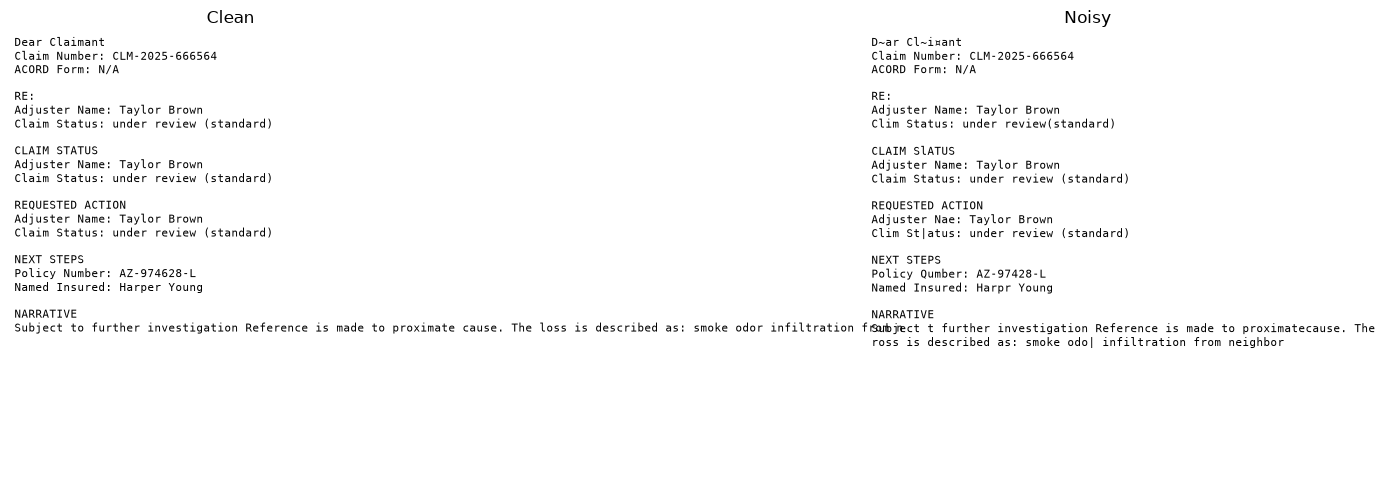

Multi-doc groups: 4
  example GRP-67154: ['CLM-2025-440870::loss_notice::13', 'CLM-2025-440870::supporting_evidence::14', 'CLM-2025-440870::claims_correspondence::15']


In [7]:
from src.generation.noise_injection import run_noise

noisy_path = run_noise(cfg, doc_path, out=DEMO / f"noisy_n{N}_seed{SEED}.jsonl", seed=SEED)
noisy_docs = load_jsonl(noisy_path)

# Side-by-side clean vs noisy excerpt
clean_excerpt = docs[0]["text"][:500]
noisy_excerpt = noisy_docs[0]["text"][:500]
display(Markdown("### Clean vs OCR-noisy (first ~500 chars)"))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, title, text in (
    (axes[0], "Clean", clean_excerpt),
    (axes[1], "Noisy", noisy_excerpt),
):
    ax.axis("off")
    ax.set_title(title)
    ax.text(0.01, 0.99, text, va="top", ha="left", family="monospace", fontsize=8, wrap=True,
            transform=ax.transAxes)
plt.tight_layout()
plt.show()

index_path = cfg.noisy_output_dir / f"multi_doc_index_from_{doc_path.stem}.json"
if index_path.exists():
    index = read_json(index_path)
    print(f"Multi-doc groups: {len(index)}")
    if index:
        gid, members = next(iter(index.items()))
        print(f"  example {gid}: {members}")


## 7. Classification — prepare dataset

Maps Stage A documents → taxonomy labels using the fixed splits. Writes `train/val/test.jsonl` + `label2id.json`.


In [8]:
from src.classification.prepare_dataset import prepare as prepare_classification

clf_prepared = prepare_classification(doc_path, cfg, out_dir=DEMO / "classification_prepared")
summary = read_json(clf_prepared / "summary.json")
label2id = read_json(clf_prepared / "label2id.json")
print("Prepared:", clf_prepared)
print("Split sizes:", {k: summary[k] for k in ("train", "val", "test")})
print("Labels:", summary["labels"])

train_rows = load_jsonl(clf_prepared / "train.jsonl")
display(pd.Series([r["label"] for r in train_rows]).value_counts().rename("train_count").to_frame())


Prepared: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/classification_prepared
Split sizes: {'train': 34, 'val': 7, 'test': 7}
Labels: ['application_commercial', 'application_personal', 'certificate_evidence', 'loss_notice', 'claims_correspondence', 'policy_change_endorsement', 'repair_estimate', 'supporting_evidence']


,train_count
repair_estimate,7
claims_correspondence,6
loss_notice,6
supporting_evidence,4
application_personal,3
certificate_evidence,3
application_commercial,3
policy_change_endorsement,2


## 8. Classification — train (smoke)

Smoke mode fine-tunes **DistilBERT** for a few steps on CPU. Full runs use `microsoft/deberta-v3-base` with `SMOKE=False`.


In [9]:
from src.classification.train_classifier import train as train_classifier

clf_model_dir = train_classifier(
    clf_prepared,
    cfg,
    output_dir=DEMO / "models" / ("classifier_smoke" if SMOKE else "classifier"),
    smoke=SMOKE,
    max_steps=30 if SMOKE else None,
)
meta = read_json(clf_model_dir / "train_meta.json")
print("Saved classifier →", clf_model_dir)
print(json.dumps(meta, indent=2))


INFO src.utils.wandb_utils: WANDB_API_KEY unset; using offline mode for local logging


INFO httpx: HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=tr

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/34 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Macro F1
1.886088,1.875875,30,0.428571,0.300000


eval/accuracy,▁▁▁
eval/loss,█▁▁
eval/macro_f1,▁██
eval/runtime,▃▁█
eval/samples_per_second,▃█▁
eval/steps_per_second,▃█▁
final/epoch,▁
final/eval_accuracy,▁
final/eval_loss,▁
final/eval_macro_f1,▁
+10,...


Saved classifier → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/models/classifier_smoke
{
  "model_name": "distilbert-base-uncased",
  "smoke": true,
  "n_train": 34,
  "n_val": 7,
  "max_steps": 30,
  "metrics": {
    "train_runtime": 19.9727,
    "train_samples_per_second": 6.008,
    "train_steps_per_second": 1.502,
    "total_flos": 5883527351136.0,
    "train_loss": 1.980633544921875,
    "epoch": 3.3333333333333335,
    "eval_loss": 1.8758752346038818,
    "eval_accuracy": 0.42857142857142855,
    "eval_macro_f1": 0.3
  }
}


## 9. Classification — evaluate

Accuracy, macro-F1, per-class report, and confusion matrix on the held-out test split. Reports also land under `evaluation/reports/`.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


eval/accuracy,▁
eval/macro_f1,▁
eval/n,▁
accuracy,0.42857
eval/accuracy,0.42857
eval/macro_f1,0.34444
eval/n,7
macro_f1,0.34444
n,7
split,test


accuracy=0.4286  macro_f1=0.3444  n=7


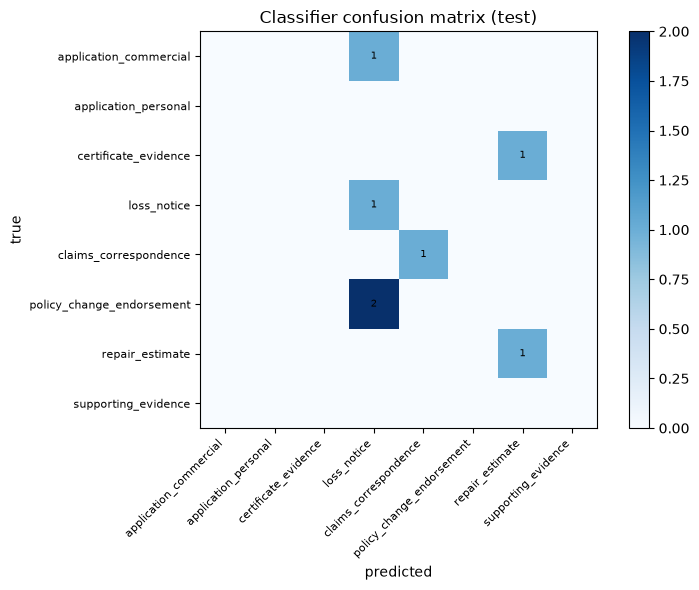

,true,pred,count
0,policy_change_endorsement,loss_notice,2
1,application_commercial,loss_notice,1
2,certificate_evidence,repair_estimate,1


In [10]:
from src.classification.eval import evaluate as eval_classifier
import numpy as np

clf_report = eval_classifier(clf_model_dir, clf_prepared, cfg, split="test")
print(f"accuracy={clf_report['accuracy']:.4f}  macro_f1={clf_report['macro_f1']:.4f}  n={clf_report['n']}")

labels = clf_report["labels"]
cm = np.array(clf_report["confusion_matrix"])
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Classifier confusion matrix (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j]:
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

if clf_report["top_confusion_pairs"]:
    display(pd.DataFrame(clf_report["top_confusion_pairs"]))
else:
    print("No off-diagonal confusions on this tiny smoke run.")


## 10. Extraction — render forms

Turns document text into page images with word bounding boxes and BIO field labels (claim id, policy number, amounts, dates, …).


Rendered 48 pages → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/rendered/rendered.jsonl


### Rendered page — `claims_correspondence`

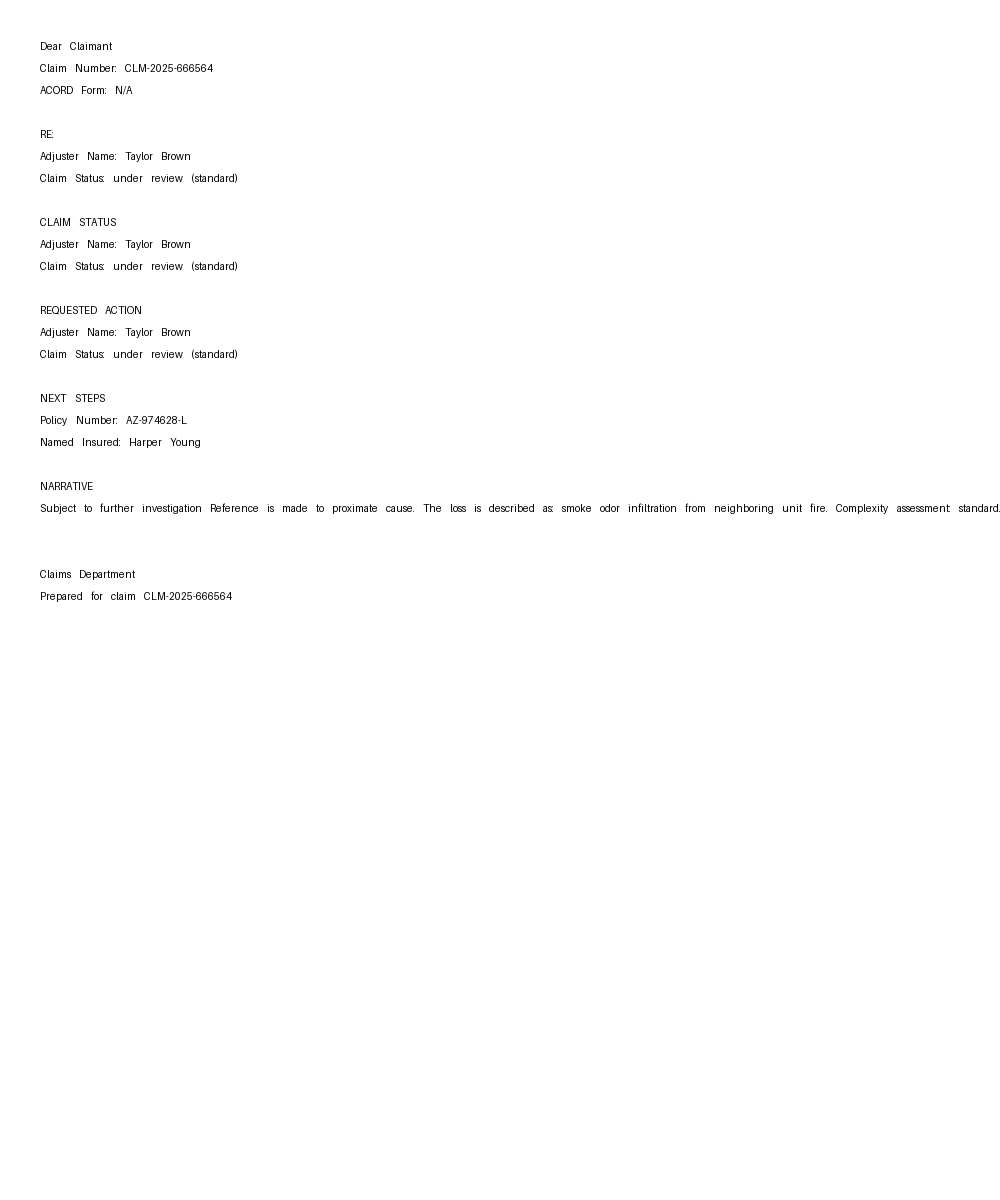

,text,bbox,line_idx,label
0,CLM-2025-666564,"[125, 64, 213, 72]",1,B-claim_id
1,Taylor,"[125, 152, 153, 162]",5,B-adjuster_assigned
2,Brown,"[161, 152, 191, 160]",5,I-adjuster_assigned
3,Taylor,"[125, 240, 153, 250]",9,B-adjuster_assigned
4,Brown,"[161, 240, 191, 248]",9,I-adjuster_assigned
5,Taylor,"[125, 328, 153, 338]",13,B-adjuster_assigned
6,Brown,"[161, 328, 191, 336]",13,I-adjuster_assigned
7,AZ-974628-L,"[126, 416, 187, 424]",17,B-policy_number
8,Harper,"[129, 438, 162, 448]",18,B-policyholder_name
9,Young,"[170, 438, 201, 448]",18,I-policyholder_name


Non-O tokens on page: 10 / 81


In [11]:
from src.extraction.render_forms import render_documents

rendered_dir = DEMO / "rendered"
rendered_path = render_documents(doc_path, rendered_dir)
rendered = load_jsonl(rendered_path)
print(f"Rendered {len(rendered)} pages → {rendered_path}")

page = rendered[0]
display(Markdown(f"### Rendered page — `{page['document_type']}`"))
display(Image(filename=page["image_path"], width=520))

labeled = [w for w in page["words"] if w.get("label", "O") != "O"]
display(pd.DataFrame(labeled[:20]))
print(f"Non-O tokens on page: {len(labeled)} / {len(page['words'])}")


## 11. Extraction — prepare dataset

Token/bbox/label rows split with the same `splits.json` as classification.


In [12]:
from src.extraction.prepare_dataset import prepare as prepare_extraction

ext_prepared = prepare_extraction(rendered_path, cfg, out_dir=DEMO / "extraction_prepared")
ext_summary = read_json(ext_prepared / "summary.json")
print("Prepared:", ext_prepared)
print(ext_summary)

# Also prepare noisy renders for stress eval (optional but useful)
noisy_rendered_dir = DEMO / "rendered_noisy"
noisy_rendered_path = render_documents(noisy_path, noisy_rendered_dir)
noisy_ext_prepared = prepare_extraction(
    noisy_rendered_path, cfg, out_dir=DEMO / "extraction_prepared_noisy"
)
print("Noisy prepared:", noisy_ext_prepared)


Prepared: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/extraction_prepared
{'train': 34, 'val': 7, 'test': 7, 'split_misses': 0}
Noisy prepared: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/extraction_prepared_noisy


## 12. Extraction — train (smoke)

Smoke path uses a text-only DistilBERT token classifier (LayoutLMv3 is heavy on CPU). Full runs use `microsoft/layoutlmv3-base` with images + boxes.


In [13]:
from src.extraction.train_extractor import train as train_extractor

ext_model_dir = train_extractor(
    ext_prepared,
    cfg,
    output_dir=DEMO / "models" / ("extractor_smoke" if SMOKE else "extractor"),
    smoke=SMOKE,
    max_steps=20 if SMOKE else None,
)
ext_meta = read_json(ext_model_dir / "train_meta.json")
print("Saved extractor →", ext_model_dir)
print(json.dumps(ext_meta, indent=2))


INFO httpx: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO httpx: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: HEAD https://huggingface.co/dis

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Token Macro F1
0.657812,0.630751,20,0.056553


eval/loss,█▁▁
eval/runtime,█▂▁
eval/samples_per_second,▁▅█
eval/steps_per_second,▁▅█
eval/token_macro_f1,▁▁▁
final/epoch,▁
final/eval_loss,▁
final/eval_token_macro_f1,▁
final/total_flos,▁
final/train_loss,▁
+8,...


Saved extractor → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/models/extractor_smoke
{
  "model_name": "distilbert-base-uncased",
  "smoke": true,
  "n_train": 24,
  "metrics": {
    "train_runtime": 19.7084,
    "train_samples_per_second": 2.03,
    "train_steps_per_second": 1.015,
    "total_flos": 1931137715496.0,
    "train_loss": 1.1331048369407655,
    "epoch": 1.6666666666666665,
    "eval_loss": 0.6307505369186401,
    "eval_token_macro_f1": 0.056552768166089964
  }
}


## 13. Extraction — evaluate (+ noisy stress)

Token macro-F1, field exact/partial match, hard-field breakdown, and optional noisy-split stress metrics. Writes `evaluation/reports/extraction_report.json` and `failure_modes.md`.


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

eval/field_exact_mean,▁
eval/field_partial_mean,▁
eval/n,▁
eval/noisy_field_exact_mean,▁
eval/noisy_field_partial_mean,▁
eval/noisy_token_macro_f1,▁
eval/token_macro_f1,▁
eval/field_exact_mean,0
eval/field_partial_mean,0
eval/n,7
eval/noisy_field_exact_mean,0


token_macro_f1=0.0529  field_exact=0.0000  field_partial=0.0000
noisy stress: {'token_macro_f1': 0.06343178621659634, 'field_exact_mean': 0.0, 'field_partial_mean': 0.0}


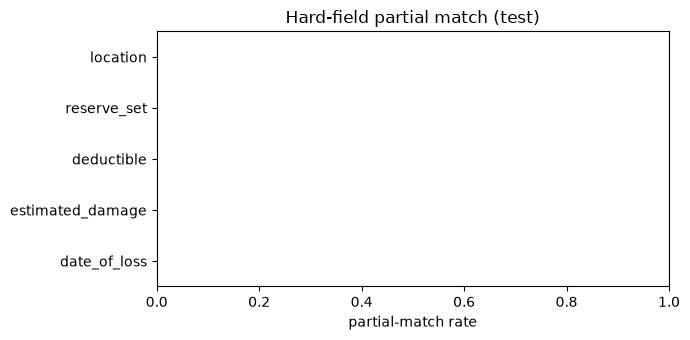

### Failure-mode notes

# Extraction failure modes

Observed / expected hard fields on synthetic forms:

- **Dates (`date_of_loss`, `effective_date`)**: OCR digit confusions (0/O, 1/l) and format variation.
- **Dollar amounts (`estimated_damage`, `deductible`, `reserve_set`)**: commas, `$` glyphs, and OCR substitutions.
- **Free-text location / narrative-adjacent values**: long spans bleed into neighboring fields under BIO labeling.
- **Noisy variants**: token F1 and field exact-match drop vs clean renders; partial match remains more stable.

## Measured hard-field partial match

- `date_of_loss`: 0.000
- `estimated_damage`: 0.000
- `deductible`: 0.000
- `reserve_set`: 0.000
- `location`: 0.000

## Noisy stress summary

- token_macro_f1: 0.063
- field_exact_mean: 0.000
- field_partial_mean: 0.000



In [14]:
from src.extraction.eval import evaluate as eval_extractor

ext_report = eval_extractor(
    ext_model_dir,
    ext_prepared,
    cfg,
    split="test",
    noisy_prepared=noisy_ext_prepared,
)
print(
    f"token_macro_f1={ext_report['token_macro_f1']:.4f}  "
    f"field_exact={ext_report['field_exact_mean']:.4f}  "
    f"field_partial={ext_report['field_partial_mean']:.4f}"
)
if ext_report.get("noisy_stress"):
    print("noisy stress:", ext_report["noisy_stress"])

hard = pd.Series(ext_report["hard_fields"]).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
hard.plot(kind="barh", ax=ax, color="#8b5e3c")
ax.set_xlim(0, 1)
ax.set_xlabel("partial-match rate")
ax.set_title("Hard-field partial match (test)")
plt.tight_layout()
plt.show()

display(Markdown("### Failure-mode notes"))
print((cfg.evaluation_reports_dir / "failure_modes.md").read_text(encoding="utf-8"))


## 14. End-to-end inference on one document

Classify a held-out document, run token-level field extraction, and show the paired Stage B memo (the Phase 4 summarization target — not yet a trained local generator).


In [15]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    AutoTokenizer,
)

test_rows = load_jsonl(clf_prepared / "test.jsonl")
assert test_rows, "Need at least one test row — raise N if empty"
row = test_rows[0]
record_id = row["record_id"]

# --- Classify ---
clf_tok = AutoTokenizer.from_pretrained(str(clf_model_dir))
clf_model = AutoModelForSequenceClassification.from_pretrained(str(clf_model_dir))
clf_model.eval()
with torch.no_grad():
    inputs = clf_tok(row["text"], return_tensors="pt", truncation=True, max_length=512)
    pred_id = int(torch.argmax(clf_model(**inputs).logits, dim=-1).item())
pred_label = clf_model.config.id2label[pred_id]

# --- Extract fields from matching rendered page ---
ext_test = {r["record_id"]: r for r in load_jsonl(ext_prepared / "test.jsonl")}
ext_row = ext_test.get(record_id) or load_jsonl(ext_prepared / "train.jsonl")[0]
ext_tok = AutoTokenizer.from_pretrained(str(ext_model_dir))
ext_model = AutoModelForTokenClassification.from_pretrained(str(ext_model_dir))
ext_model.eval()
id2label = {int(v): k for k, v in read_json(ext_model_dir / "label2id.json").items()}

enc = ext_tok(
    ext_row["tokens"],
    is_split_into_words=True,
    return_tensors="pt",
    truncation=True,
    max_length=256,
)
with torch.no_grad():
    pred_ids = torch.argmax(ext_model(**enc).logits, dim=-1)[0].tolist()
word_ids = enc.word_ids(batch_index=0)
aligned = ["O"] * len(ext_row["tokens"])
seen = set()
for idx, wid in enumerate(word_ids):
    if wid is None or wid in seen:
        continue
    seen.add(wid)
    aligned[wid] = id2label.get(int(pred_ids[idx]), "O")

# Decode BIO spans
from src.extraction.eval import _decode_entities

pred_ents = _decode_entities(ext_row["tokens"], aligned)
gold_ents = _decode_entities(
    ext_row["tokens"], [id2label.get(int(i), "O") for i in ext_row["labels"]]
)

# --- Paired memo ---
memo_by_id = {m["record_id"]: m for m in memos}
paired_memo = memo_by_id.get(record_id)

display(Markdown(f"### Record `{record_id}`"))
print(f"Gold label:      {row['label']}")
print(f"Predicted label: {pred_label}")
print()
print("Extracted fields (pred vs gold):")
fields = sorted(set(pred_ents) | set(gold_ents))
for f in fields:
    pvals = pred_ents.get(f) or []
    gvals = gold_ents.get(f) or []
    pred_s = (pvals[0][:60] if pvals else "—")
    gold_s = (gvals[0][:60] if gvals else "—")
    print(f"  {f:22s}  pred={pred_s}")
    print(f"  {'':22s}  gold={gold_s}")

if paired_memo:
    display(Markdown("### Paired Stage B memo (summarization training target)"))
    print(paired_memo["memo_text"][:1800])


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

### Record `CLM-2023-720893::application_commercial::9`

Gold label:      application_commercial
Predicted label: loss_notice

Extracted fields (pred vs gold):
  claim_id                pred=—
                          gold=CLM-2023-720893
  coverage_type           pred=—
                          gold=commercial_property
  date_of_loss            pred=—
                          gold=2023-12-06
  deductible              pred=—
                          gold=$500.00
  effective_date          pred=—
                          gold=2022-11-03
  estimated_damage        pred=—
                          gold=$6,258.27
  location                pred=—
                          gold=8380 Sunset Ave, MD
  loss_type               pred=—
                          gold=wind_hail
  policy_number           pred=—
                          gold=MD-765046-I
  policyholder_name       pred=—
                          gold=Skyler Martinez
  reserve_set             pred=—
                          gold=$6,753.30
  state                   pred=—
                

### Paired Stage B memo (summarization training target)

ADJUSTER MEMO — CLM-2023-720893
To: Claims File
From: Jordan Nguyen
Re: Skyler Martinez / MD-765046-I

Summary
The claimant alleges the reported wind_hail loss on 2023-12-06 under commercial_property in MD.

Facts
- Location: 8380 Sunset Ave, MD
- Description: wind-driven tree limb through living room window
- Police report: no
- Injuries: no
- Estimated damage: $6,258.27
- Deductible: $500.00
- Current reserve: $6,753.30

Analysis
The record supports a finding that the claim file for CLM-2023-720893 is fraud_flagged, because wind-driven tree limb through living room window. Alternative explanations are less consistent with the Stage A source document and reported loss details.

Next Steps
- Confirm coverage grant/denial points in writing
- Update reserve if investigation changes exposure
- Request any missing supporting evidence

Source document type: application_commercial


## 15. Provenance audit log

Every generation and training stage appends a record to `data/provenance_log.jsonl`.


In [16]:
prov_path = cfg.provenance_log_path
if prov_path.exists():
    prov = load_jsonl(prov_path)
    # Show the most recent entries from this notebook run
    recent = prov[-12:]
    display(pd.DataFrame(
        [
            {
                "stage": r.get("stage"),
                "source": str(r.get("source", ""))[:50],
                "model": r.get("model"),
                "prompt_version": r.get("prompt_version"),
            }
            for r in recent
        ]
    ))
    print(f"Total provenance records: {len(prov)}  → {prov_path}")
else:
    print("No provenance log yet.")


,stage,source,model,prompt_version
0,classification_train_random_forest,/private/var/folders/fv/7353h_0d5jzfv61r_mhb5_...,sklearn.RandomForestClassifier,random_forest_multilayer_v1
1,characteristic_profiling,data/profiles,NaN,profiles_v1
2,skeleton_sampling,insurance_distributions.json,NaN,skeleton_sampler_v1
3,stage_a_document_gen,/Users/morningstar/Desktop/Cold_Storage/smol-d...,template_renderer,stage_a_v1
4,stage_b_memo_gen,/Users/morningstar/Desktop/Cold_Storage/smol-d...,template_renderer,stage_b_v1
5,noise_injection,/Users/morningstar/Desktop/Cold_Storage/smol-d...,NaN,noise_injection_v1
6,classification_train,/Users/morningstar/Desktop/Cold_Storage/smol-d...,distilbert-base-uncased,classification_v1
7,classification_train_random_forest,/private/var/folders/fv/7353h_0d5jzfv61r_mhb5_...,sklearn.RandomForestClassifier,random_forest_multilayer_v1
8,classification_train_random_forest,/Users/morningstar/Desktop/Cold_Storage/smol-d...,sklearn.RandomForestClassifier,random_forest_multilayer_v1
9,docie_pipeline,/Users/morningstar/Desktop/Cold_Storage/smol-d...,document_processing→document_classification→in...,docie_fig1_v1


Total provenance records: 46  → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/provenance_log.jsonl


## 16. Pipeline map & next steps

```
Public priors / optional Hub ingest
        ↓
Characteristic profiles
        ↓
Claim skeletons ──► Stage A documents ──► Stage B memos (Phase 4 targets)
        │                    │
        │                    ├── OCR-noisy variants
        │                    ↓
        │              Classification (DeBERTa / DistilBERT smoke)
        │                    ↓
        │              Form render + Extraction (LayoutLMv3 / DistilBERT smoke)
        ↓
Fixed splits.json reused across train/eval
```

| Phase | Status in this notebook |
|-------|-------------------------|
| 0 Taxonomy / schema / config | ✅ inspected |
| 1 Synthetic generation + noise | ✅ ran |
| 2 Classification train/eval | ✅ smoke |
| 3 Extraction train/eval | ✅ smoke |
| 4 Summarization LoRA | ❌ not implemented — template memo + optional local generative hook |
| 5 Orchestrated intake pipeline | ✅ implemented (`src/pipeline/`) |

**Scale up:** set `N=240` (or 5000), `SMOKE=False`, and optionally export `OPENROUTER_API_KEY` for LLM Stage A/B. CLI equivalents are in the README quickstart.


In [17]:
print("Demo artifact summary")
print("=" * 60)
for label, path in [
    ("skeletons", sk_path),
    ("documents", doc_path),
    ("memos", memo_path),
    ("noisy", noisy_path),
    ("clf prepared", clf_prepared),
    ("clf model", clf_model_dir),
    ("rendered", rendered_path),
    ("ext prepared", ext_prepared),
    ("ext model", ext_model_dir),
    ("clf report", cfg.evaluation_reports_dir / "classification_report.json"),
    ("ext report", cfg.evaluation_reports_dir / "extraction_report.json"),
]:
    print(f"{label:14s} {path}")


Demo artifact summary
skeletons      /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/skeletons_n48_seed42.jsonl
documents      /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/documents_n48_seed42.jsonl
memos          /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/memos_n48_seed42.jsonl
noisy          /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/noisy_n48_seed42.jsonl
clf prepared   /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/classification_prepared
clf model      /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/models/classifier_smoke
rendered       /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/rendered/rendered.jsonl
ext prepared   /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/extraction_prepared
ext model      /Users/morningstar/Desktop/Cold_Sto